# Tier 20: tiltrotor airframe weights (AFDD tiltrotor wing)

Tier 10a showed that the Raymer general-aviation wing predicts 452 lb for the XV-15 against an 873 lb
statement (factor 1.93). A tiltrotor wing is sized by stiffness, not strength. The wing must keep its torsion
and bending modes clear of the proprotor whirl modes, so this tier adds the **AFDD tiltrotor wing** of NDARC
(Johnson, NASA/TP-2009-215402, sec. 19-1.1, after Chappell and Peyran, SAWE 2107, 1992). It is selected
through `Wing.mass_model`; the Raymer wing stays as the simplest model and the default.

**Model** (`weights/afdd.py` `wing_tiltrotor_afdd_masses`; `vehicle/surfaces.py` `TiltrotorWingMassModel`):

1. **Torque box from the torsion frequency:** GJ = (w_T Omega)^2 (b/2) (M_tip r_pylon^2 / 2), and
   A_tb = 4 GJ / (G F_T t^2).
2. **Spar caps for the chord and beam bending frequencies:** EI = (w Omega)^2 b^3/24 (M_tip f_mode / 2), less the
   torque-box contribution.
3. **Jump take-off:** extra caps for the 2-g ultimate root moment.
4. **Non-structural items:** fairings and control surfaces by unit mass, fittings by fraction; fold is optional.

Frequencies are **per rev** of a design rotor speed. In the Halo sizing that speed is a design variable, and a
**whirl-flutter margin** at every airplane-mode point keeps the realized torsion and beam frequencies at or above
the required placement at that point's rotor speed. The margin is a constraint, not a hidden loop.

**Data** (`data/weights/tiltrotor_wing_reference.csv`, citations in `data/weights/sources.csv`):

- **XV-15:**
  - wing breakdown, stiffness and materials: Acree, Peyran and Johnson, AHS 1999, table 5;
  - modes and tip masses: NASA/TP-2004-212262, appendices C and D;
  - group statement: TM X-62407.
- **V-22 FSD:** wing about 2,470 lb (Popelka et al., AHS 1995: a 2,500 lb tailored wing is +29 lb).
- **Bell D266:** MIL-STD-451 group statement of the 1968 preliminary design (Harris, NASA/SP-2015-215959
  vol. III).

No public V-22 or AW609 group weight statement was found, so the second-aircraft check covers the groups that
are published.

In [1]:
import sys
from dataclasses import fields, replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.vehicle.condition import StructuralDesignCondition
from aircraft_closure.vehicle.surfaces import TiltrotorWingMassModel, Wing
from aircraft_closure.weights import afdd
from examples.tiltrotor_wing_calibration import (d266_rotor_implied_solidity, d266_wing_check, load_reference_data,
                                                 v22_wing_check, xv15_frequency_stiffness_ratios,
                                                 xv15_section_calibration)
from examples.xv15_reference import (Xv15MassFactors, Xv15Reference, build_xv15_aircraft, calibration_factors,
                                     compare_groups, design_condition, mass_turboshaft_from_power_kg, published_groups,
                                     solve_xv15_closure, xv15_wing_mass_model)
from examples.halo_sizing import (HaloAssumptions, HaloRequirements, halo_equipment_items, solve_halo_sizing)

# Current defaults (780 kg payload, equivalent-circuit battery, Raymer wing) plus the Tier 20 flag.
assumptions_raymer = HaloAssumptions()
assumptions_afdd = HaloAssumptions(wing_weight_model="afdd_tiltrotor")

check_log = []


def check(name, passed):
    # Record and print one named verification.
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
ramp = ["#0d366b", "#184f95", "#256abf", "#3987e5", "#6da7ec", "#9ec5f4"]   # ordinal (blue 700 -> 200)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8,
                     "axes.labelcolor": ink, "xtick.color": ink_muted, "ytick.color": ink_muted})
data = load_reference_data()
reference = Xv15Reference()
mass_engine_kg = mass_turboshaft_from_power_kg(reference.power_takeoff_engine_W)
factors = calibration_factors(mass_engine_kg=mass_engine_kg)

## 1. XV-15 section calibration

The published XV-15 stiffness (GJ, EI beam, EI chord), materials (aluminium) and component weights fix NDARC's
section constants. The torque-box chord ratio is not published; 0.45 is assumed. NDARC's torque-box area for
the published GJ, against the 567 lb box, gives the structural efficiency e_tb. The spar-cap area for the
published EI, against the 52 lb of spars, gives the taper correction C_t. These are the
`TiltrotorWingMassModel` defaults.

In [2]:
calibration = xv15_section_calibration()
defaults = TiltrotorWingMassModel(mass_tip_kg=1.0, radius_gyration_pylon_m=1.0, speed_rotor_design_rad_s=1.0,
                                  width_fuselage_m=1.0)
for f in fields(calibration):
    print(f"{f.name:<36}{getattr(calibration, f.name):10.4f}   default {getattr(defaults, f.name):10.4f}")
check("model defaults equal the XV-15 section calibration (0.5 %)",
      all(abs(getattr(defaults, f.name) / getattr(calibration, f.name) - 1) < 0.005 for f in fields(calibration)))
sensitivity = {w: xv15_section_calibration(w) for w in (0.35, 0.40, 0.45, 0.50, 0.55)}
for w, c in sensitivity.items():
    print(f"torque-box chord ratio {w:.2f}: e_tb {c.efficiency_torque_box:.3f}, C_t {c.correction_spar_stiffness:.3f}")

efficiency_torque_box                   0.5826   default     0.5830
correction_spar_stiffness               0.5262   default     0.5260
unit_mass_fairing_kg_m2                10.9248   default    10.9200
unit_mass_control_surfaces_kg_m2       15.1793   default    15.1800
fraction_fittings                       0.1290   default     0.1290
fraction_area_control_surfaces          0.1846   default     0.1850
PASS  model defaults equal the XV-15 section calibration (0.5 %)
torque-box chord ratio 0.35: e_tb 0.707, C_t 0.360
torque-box chord ratio 0.40: e_tb 0.635, C_t 0.531
torque-box chord ratio 0.45: e_tb 0.583, C_t 0.526
torque-box chord ratio 0.50: e_tb 0.544, C_t 0.506
torque-box chord ratio 0.55: e_tb 0.515, C_t 0.482


## 2. Frequencies to stiffness, and the XV-15 wing group

Next the model is driven the way it is used in sizing: by frequencies. The XV-15 published symmetric modes at
its 458 rpm airplane-mode rotor speed are torsion 8.3 Hz (1.09/rev), beam 3.3 Hz (0.43/rev) and chord 6.3 Hz
(0.83/rev). The tip mass, 2,142 lb per side, and the pylon radius of gyration, 2.77 ft (0.222 R), come from
the NASTRAN stick model. NDARC's single-mode relations then give about 0.6 of the published stiffness. That is
the model-form error of a reduced-order wing, so the wing is lighter than the statement.
`Xv15MassFactors.wing_tiltrotor` = 873 lb / model carries the difference. It is a separate factor; the Raymer
`wing` factor (1.93) is unchanged.

model / published stiffness (torsion, beam, chord): 0.574, 0.585, 0.623
PASS  frequency-driven stiffness within 0.5-0.7 of published (regression band)
XV-15 AFDD wing (x1): 658 lb; statement 873 lb; Acree breakdown 946 lb
factors: wing (Raymer) 1.930, wing_tiltrotor 1.327
PASS  wing_tiltrotor factor 1.33 +- 0.01
PASS  Raymer wing factor unchanged (1.93)
PASS  calibrated AFDD-wing XV-15 reproduces the statement


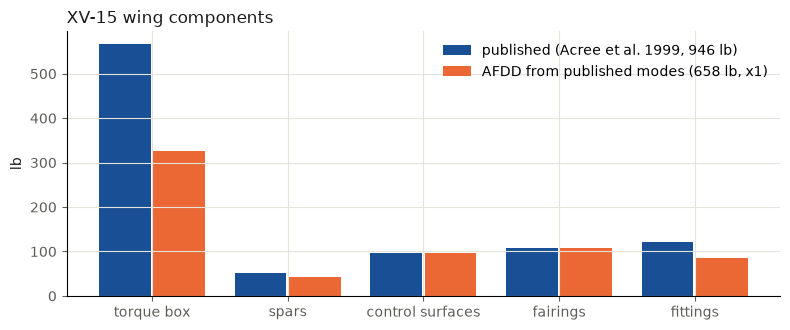

In [3]:
ratios = xv15_frequency_stiffness_ratios()
print("model / published stiffness (torsion, beam, chord):", ", ".join(f"{r:.3f}" for r in ratios))
check("frequency-driven stiffness within 0.5-0.7 of published (regression band)", all(0.5 < r < 0.7 for r in ratios))

wing = build_xv15_aircraft(reference, Xv15MassFactors(), mass_engine_kg, "afdd_tiltrotor").wing
xv15_masses = wing.mass_model.masses(wing, design_condition(reference.mass_design_kg, reference))
print(f"XV-15 AFDD wing (x1): {float(xv15_masses.total()) / u.lbm:.0f} lb; statement 873 lb; "
      f"Acree breakdown 946 lb")
print(f"factors: wing (Raymer) {factors.wing:.3f}, wing_tiltrotor {factors.wing_tiltrotor:.3f}")
check("wing_tiltrotor factor 1.33 +- 0.01", abs(factors.wing_tiltrotor - 1.327) < 0.01)
check("Raymer wing factor unchanged (1.93)", abs(factors.wing - 1.930) < 0.005)
groups = compare_groups(factors=factors, mass_engine_kg=mass_engine_kg, wing_weight_model="afdd_tiltrotor")
check("calibrated AFDD-wing XV-15 reproduces the statement", all(
    abs(getattr(groups, f.name) / getattr(published_groups, f.name) - 1) < 1e-6 for f in fields(groups)))

labels = ["torque box", "spars", "control surfaces", "fairings", "fittings"]
published = [567, 52, 97, 108, 122]
model = [xv15_masses.mass_torque_box_kg, xv15_masses.mass_spar_stiffness_kg + xv15_masses.mass_spar_jump_kg,
         xv15_masses.mass_control_surfaces_kg, xv15_masses.mass_fairing_kg, xv15_masses.mass_fittings_kg]
model = [float(m) / u.lbm for m in model]
fig, ax = plt.subplots(figsize=(8, 3.4))
x = np.arange(len(labels))
ax.bar(x - 0.2, published, 0.38, color=ramp[1], label="published (Acree et al. 1999, 946 lb)")
ax.bar(x + 0.2, model, 0.38, color=orange, label=f"AFDD from published modes ({sum(model):.0f} lb, x1)")
ax.set_xticks(x, labels)
ax.set_ylabel("lb")
ax.set_title("XV-15 wing components", color=ink, loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 3. Identities, limits and trends

These spot checks come from the analytic tests (`tests/weights/test_tiltrotor_wing.py`):

- the box mass scales with the square of the torsion frequency;
- the wing gets heavier with span, design mass (through the jump take-off) and tip mass;
- with no bending requirement there are no stiffness caps;
- the realized torsion frequency equals the requirement.

PASS  wing mass rises with torsion frequency
PASS  wing mass rises with span (fixed chord)
PASS  wing mass does not fall with design mass (jump take-off)
PASS  box mass scales with torsion frequency squared
PASS  realized torsion frequency equals the requirement


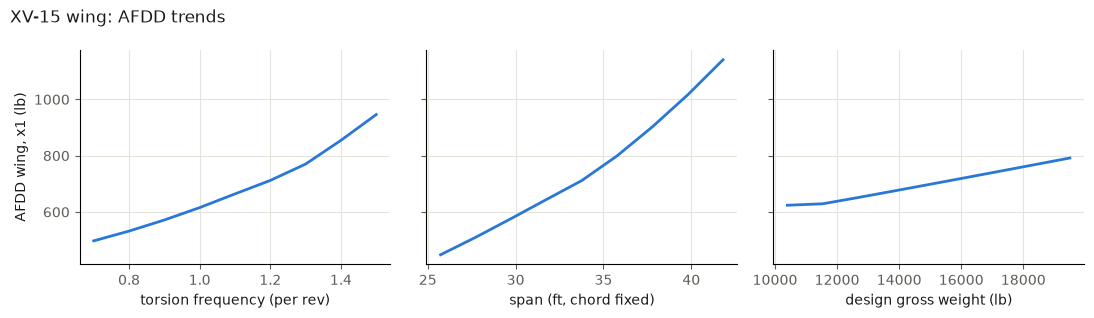

In [4]:
model = xv15_wing_mass_model(reference)
base_wing = Wing(area_m2=reference.area_wing_m2, aspect_ratio=reference.aspect_ratio_wing, mass_model=model)


def total_lb(model=model, wing=base_wing, mass_kg=reference.mass_design_kg):
    return float(model.mass_kg(wing, StructuralDesignCondition(mass_design_kg=mass_kg))) / u.lbm


frequencies = np.linspace(0.7, 1.5, 9)
spans = np.linspace(0.8, 1.3, 9)
design_masses = np.linspace(0.8, 1.5, 9)
by_frequency = [total_lb(replace(model, frequency_torsion_per_rev=f)) for f in frequencies]
by_span = [total_lb(wing=replace(base_wing, area_m2=reference.area_wing_m2 * s,
                                 aspect_ratio=reference.aspect_ratio_wing * s)) for s in spans]
by_design_mass = [total_lb(mass_kg=reference.mass_design_kg * m) for m in design_masses]
check("wing mass rises with torsion frequency", np.all(np.diff(by_frequency) > 0))
check("wing mass rises with span (fixed chord)", np.all(np.diff(by_span) > 0))
check("wing mass does not fall with design mass (jump take-off)", np.all(np.diff(by_design_mass) >= -1e-9))
condition = StructuralDesignCondition(mass_design_kg=reference.mass_design_kg)
box = lambda f: float(replace(model, frequency_torsion_per_rev=f).masses(base_wing, condition).mass_torque_box_kg)
check("box mass scales with torsion frequency squared", abs(box(2.0) / box(1.0) - 4.0) < 1e-9)
xm = model.masses(base_wing, condition)
check("realized torsion frequency equals the requirement",
      abs(float(xm.frequency_torsion_rad_s) / reference.speed_rotor_airplane_rad_s
          - reference.frequency_torsion_wing_per_rev) < 1e-9)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, xs, ys, xlabel in ((axes[0], frequencies, by_frequency, "torsion frequency (per rev)"),
                           (axes[1], spans * reference.area_wing_m2**0.5 * reference.aspect_ratio_wing**0.5 / u.foot,
                            by_span, "span (ft, chord fixed)"),
                           (axes[2], design_masses * reference.mass_design_kg / u.lbm, by_design_mass,
                            "design gross weight (lb)")):
    ax.plot(xs, ys, color=blue, lw=2)
    ax.set_xlabel(xlabel)
axes[0].set_ylabel("AFDD wing, x1 (lb)")
fig.suptitle("XV-15 wing: AFDD trends", color=ink, x=0.01, ha="left")
plt.tight_layout()
plt.show()

## 4. Second calibration aircraft

The XV-15-calibrated model (section constants plus `wing_tiltrotor`) is applied with no further fitting:

- **V-22 FSD:**
  - graphite-epoxy material (Acree table 5), with the XV-15 frequency placement at its 333 rpm airplane-mode
    speed;
  - the tip mass is a framework model-chain estimate, because no public nacelle weights were found;
  - fold/rotate structure is excluded, because the source does not state the wing's scope.
- **Bell D266:**
  - aluminium, with the XV-15 placement at its 297 rpm maximum airplane-mode speed;
  - the tip mass is half the rotor and nacelle groups plus proprotor gearboxes;
  - t/c 0.23 and the fuselage width are assumed.

The rotor model is checked through the D266 rotor group. Its blade chord is not public, so the check reports
the solidity the XV-15-calibrated AFDD82 rotor needs to reach 2,439 lb.

aircraft               actual lb  model x1  x factor   error
XV-15 (calibration)          873       658       873   +0.0%
V-22 FSD                   2,470     1,524     2,023  -18.1%
Bell D266                  1,886     1,386     1,840   -2.4%
V-22 FSD: tip mass 6,482 lb per side; wing without fold/rotate; tip mass from the framework model chain
Bell D266: tip mass 2,117 lb per side; 1968 preliminary-design statement; t/c and fuselage width assumed
D266 rotor group 2,439 lb needs solidity 0.062 with AFDD82 x 0.69 (coning 1.55/rev)
PASS  V-22 wing: calibrated model within 25 % (under-predicts)
PASS  D266 wing: calibrated model within 10 %
PASS  D266 rotor implied solidity 0.062 (below the 0.08-0.11 of proprotors: the rotor model is heavy here)


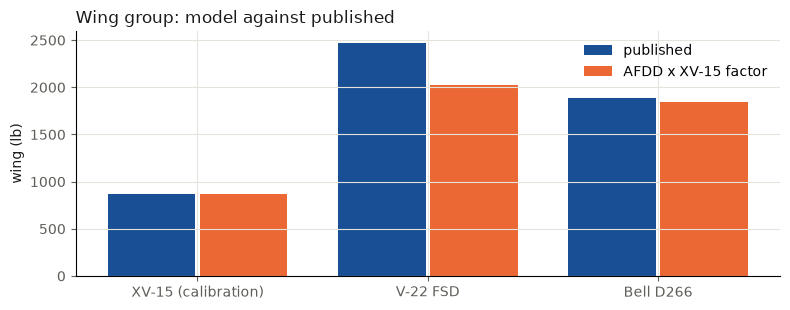

In [5]:
checks = [v22_wing_check(factors), d266_wing_check(factors)]
xv15_row = dict(aircraft="XV-15 (calibration)", actual=873.0, model=float(xv15_masses.total()) / u.lbm,
                calibrated=873.0)
rows = [xv15_row] + [dict(aircraft=c.aircraft, actual=c.mass_actual_kg / u.lbm, model=c.mass_predicted_kg / u.lbm,
                          calibrated=c.mass_predicted_calibrated_kg / u.lbm) for c in checks]
print(f"{'aircraft':<22}{'actual lb':>10}{'model x1':>10}{'x factor':>10}{'error':>8}")
for r in rows:
    print(f"{r['aircraft']:<22}{r['actual']:10,.0f}{r['model']:10,.0f}{r['calibrated']:10,.0f}"
          f"{r['calibrated'] / r['actual'] - 1:+8.1%}")
for c in checks:
    print(f"{c.aircraft}: tip mass {c.mass_tip_kg / u.lbm:,.0f} lb per side; {c.note}")
solidity = d266_rotor_implied_solidity(factors)
print(f"D266 rotor group 2,439 lb needs solidity {solidity:.3f} with AFDD82 x {factors.rotor:.2f} (coning 1.55/rev)")
check("V-22 wing: calibrated model within 25 % (under-predicts)", -0.25 < rows[1]["calibrated"] / rows[1]["actual"] - 1 < 0)
check("D266 wing: calibrated model within 10 %", abs(rows[2]["calibrated"] / rows[2]["actual"] - 1) < 0.10)
check("D266 rotor implied solidity 0.062 (below the 0.08-0.11 of proprotors: the rotor model is heavy here)",
      abs(solidity - 0.062) < 0.003)

fig, ax = plt.subplots(figsize=(8, 3.2))
x = np.arange(len(rows))
ax.bar(x - 0.2, [r["actual"] for r in rows], 0.38, color=ramp[1], label="published")
ax.bar(x + 0.2, [r["calibrated"] for r in rows], 0.38, color=orange, label="AFDD x XV-15 factor")
ax.set_xticks(x, [r["aircraft"] for r in rows])
ax.set_ylabel("wing (lb)")
ax.set_title("Wing group: model against published", color=ink, loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 5. XV-15 closure with the AFDD wing

Tier 10a's uncalibrated closure with the Raymer wing gave 11,315 lb against the 13,000 lb design. The
stiffness-based wing is nearer the statement, so the uncalibrated closure moves up. Calibrated, both wing models
reproduce 13,000 lb.

In [6]:
closures = {(model_name, label): solve_xv15_closure(factors=f, mass_engine_kg=mass_engine_kg,
                                                    wing_weight_model=model_name)
            for model_name in ("raymer", "afdd_tiltrotor")
            for label, f in (("uncalibrated", Xv15MassFactors()), ("calibrated", factors))}
for (model_name, label), c in closures.items():
    print(f"{model_name:<15}{label:<14} take-off {c.mass_takeoff_kg / u.lbm:8,.0f} lb, empty {c.mass_empty_kg / u.lbm:7,.0f} lb,"
          f" wing {c.groups.wing / u.lbm:5,.0f} lb")
check("Raymer uncalibrated closure unchanged (11,315 lb)",
      abs(closures[("raymer", "uncalibrated")].mass_takeoff_kg / u.lbm - 11315) < 10)
check("AFDD calibrated closure 13,000 lb", abs(closures[("afdd_tiltrotor", "calibrated")].mass_takeoff_kg / u.lbm - 13000) < 1)
check("AFDD uncalibrated closure heavier than Raymer's",
      closures[("afdd_tiltrotor", "uncalibrated")].mass_takeoff_kg > closures[("raymer", "uncalibrated")].mass_takeoff_kg)

raymer         uncalibrated   take-off   11,315 lb, empty   7,391 lb, wing   423 lb
raymer         calibrated     take-off   13,000 lb, empty   9,076 lb, wing   873 lb
afdd_tiltrotor uncalibrated   take-off   11,536 lb, empty   7,612 lb, wing   629 lb
afdd_tiltrotor calibrated     take-off   13,000 lb, empty   9,076 lb, wing   873 lb
PASS  Raymer uncalibrated closure unchanged (11,315 lb)
PASS  AFDD calibrated closure 13,000 lb
PASS  AFDD uncalibrated closure heavier than Raymer's


## 6. Halo with the AFDD wing

These runs use the current defaults: 780 kg payload, the equivalent-circuit battery, Tier 13 machines and the
hot-day hover. The only change is `wing_weight_model="afdd_tiltrotor"`.

- The Halo wing is graphite epoxy with t/c 0.23, and uses the XV-15 frequency placement.
- Each tip carries the rotor, motor, rotor gearbox and turbogenerator with its nacelle section.
- The pylon radius of gyration is 0.222 R.
- The wing design rotor speed is a design variable. Each airplane-mode point (climb, cruise, loiter, descent,
  maximum speed, ceiling) has whirl-flutter margins on torsion and beam frequency per rev.

Raymer (reference)   take-off   6,548 kg (14,436 lb), empty  4,779 kg, wing   547 kg, area 22.55 m2, span 11.75 m
AFDD tiltrotor       take-off   6,144 kg (13,546 lb), empty  4,401 kg, wing   372 kg, area 21.31 m2, span 11.42 m
max payload with the AFDD wing: 959 kg (reference 785 kg, plan 022)
AFDD wing breakdown (kg, before the x1.33 factor): torque_box 90.9, spar_stiffness 3.9, spar_jump 23.4, fairing 66.1, control_surfaces 59.8, fittings 36.2, fold 0.0
wing design rotor speed 39.39 rad/s
binding whirl-flutter margins: ['whirl flutter torsion per rev (max_speed)']
PASS  default (Raymer) reference unchanged: 14,436 +- 5 lb
PASS  AFDD-wing Halo closes lighter than the reference
PASS  whirl-flutter torsion margin binds at maximum speed
PASS  all whirl-flutter margins hold


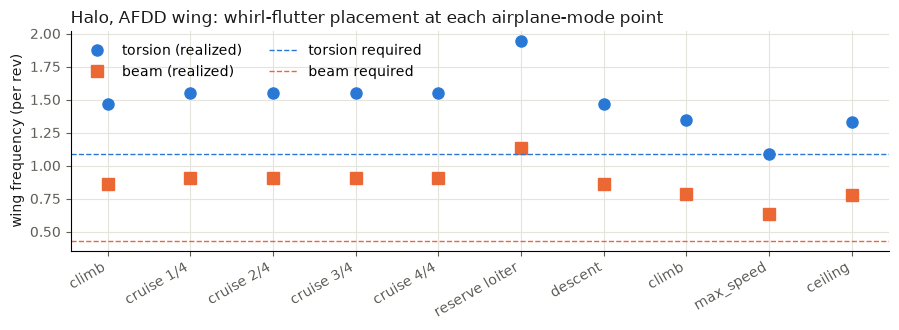

In [7]:
ref = solve_halo_sizing(HaloRequirements(), assumptions_raymer)
afdd_result = solve_halo_sizing(HaloRequirements(), assumptions_afdd)
initial = solve_halo_sizing(HaloRequirements(), replace(assumptions_afdd, battery_model="constant"), objective="payload")
afdd_payload = solve_halo_sizing(HaloRequirements(), assumptions_afdd, objective="payload", initial=initial)
for label, r in (("Raymer (reference)", ref), ("AFDD tiltrotor", afdd_result)):
    print(f"{label:<20} take-off {r.mass_takeoff_kg:7,.0f} kg ({r.mass_takeoff_kg / u.lbm:,.0f} lb), "
          f"empty {r.mass_empty_kg:6,.0f} kg, wing {dict(r.component_masses_kg)['wing']:5.0f} kg, "
          f"area {r.design.area_wing_m2:5.2f} m2, span {r.span_m:5.2f} m")
print(f"max payload with the AFDD wing: {afdd_payload.mass_payload_kg:.0f} kg (reference 785 kg, plan 022)")
print("AFDD wing breakdown (kg, before the x1.33 factor):",
      ", ".join(f"{k.replace('mass_', '').replace('_kg', '')} {v:.1f}" for k, v in afdd_result.wing_masses_kg))
print(f"wing design rotor speed {afdd_result.design.speed_rotor_wing_design_rad_s:.2f} rad/s")
whirl = [b for b in afdd_result.binding if "whirl" in b]
print("binding whirl-flutter margins:", whirl)
check("default (Raymer) reference unchanged: 14,436 +- 5 lb", abs(ref.mass_takeoff_kg / u.lbm - 14436) < 5)
check("AFDD-wing Halo closes lighter than the reference", afdd_result.mass_takeoff_kg < ref.mass_takeoff_kg)
check("whirl-flutter torsion margin binds at maximum speed", "whirl flutter torsion per rev (max_speed)" in whirl)
check("all whirl-flutter margins hold",
      all(w["torsion_per_rev"] >= assumptions_afdd.frequency_torsion_wing_per_rev - 1e-6
          and w["beam_per_rev"] >= assumptions_afdd.frequency_beam_wing_per_rev - 1e-6 for w in afdd_result.whirl_flutter))

points = afdd_result.whirl_flutter
fig, ax = plt.subplots(figsize=(9, 3.4))
x = np.arange(len(points))
ax.plot(x, [p["torsion_per_rev"] for p in points], "o", color=blue, markersize=8, label="torsion (realized)")
ax.plot(x, [p["beam_per_rev"] for p in points], "s", color=orange, markersize=8, label="beam (realized)")
ax.axhline(assumptions_afdd.frequency_torsion_wing_per_rev, color=blue, lw=1, ls="--", label="torsion required")
ax.axhline(assumptions_afdd.frequency_beam_wing_per_rev, color=orange, lw=1, ls="--", label="beam required")
ax.set_xticks(x, [p["label"] for p in points], rotation=30, ha="right")
ax.set_ylabel("wing frequency (per rev)")
ax.set_title("Halo, AFDD wing: whirl-flutter placement at each airplane-mode point", color=ink, loc="left")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

## 7. Uncrewed adjustments, itemised

Until this tier the Halo equipment was one number: 587 lb, the XV-15 electrical, instrumentation and heating
groups, with heating relabelled as autonomy. It is now built from the XV-15 groups with explicit removals and
additions, and the total is unchanged. Crew items inside other groups are not split out, because there is no
public breakdown: cockpit controls sit in flight controls, and crew-station and crash structure in the fuselage.
They stay inside those calibration factors.

In [8]:
for item in halo_equipment_items:
    print(f"{item.mass_kg / u.lbm:+8.0f} lb  {item.label}  [{item.source}]")
total_lb = sum(i.mass_kg for i in halo_equipment_items) / u.lbm
print(f"{total_lb:8.0f} lb  total")
check("itemised equipment equals the previous 587 lb", abs(total_lb - 587) < 1e-9)
check("equipment default is the itemised total", abs(HaloAssumptions().mass_equipment_kg / u.lbm - total_lb) < 1e-9)

    +396 lb  electrical  [TM X-62407 sec. 3.1.2]
     +91 lb  instrumentation  [TM X-62407 sec. 3.1.2]
    +100 lb  heating and air conditioning  [TM X-62407 sec. 3.1.2]
    +436 lb  miscellaneous (furnishings, equipment)  [TM X-62407 sec. 3.1.2]
    -100 lb  remove crew environmental control (heating, ventilation, air conditioning)  [TM X-62407 sec. 3.1.2 (the ECS serves the crew station)]
    -230 lb  remove ejection seats  [Harris, NASA/SP-2015-215959 vol. III p. 312 (from the XV-15 weight statement)]
    -206 lb  remove other furnishings and miscellaneous crew equipment  [TM X-62407 sec. 3.1.2 miscellaneous less ejection seats]
    +100 lb  add autonomy and mission avionics (flight computers, sensors, datalinks)  [assumed allocation (the XV-15 carried 144 lb of avionics as useful load, not empty weight)]
     587 lb  total
PASS  itemised equipment equals the previous 587 lb
PASS  equipment default is the itemised total


## 8. Summary and unit test suite

In [9]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

22 / 22 notebook checks passed


In [10]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 392 tests in 177.147s

OK (skipped=1)
